# 🚀 Mô hình Dự báo Baseline - Phân rã Mùa vụ (Seasonal Profile + Trend)
**Dự án:** Datathon 2026 - Team Outliers  
**Thành viên thực hiện:** Hà Quốc Khánh (ML Engineer)

**Phương pháp:** Kết hợp Hồ sơ Mùa vụ (Seasonal Profile) với Xu hướng tăng trưởng YoY.

**Công thức:** `Dự báo = Mốc cơ sở (2022) × Tốc độ tăng trưởng ^ Số năm × Hệ số mùa vụ`

## 1. Khai báo thư viện và Cấu hình

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đường dẫn dữ liệu
TRAIN_PATH = '../Data/sales.csv'
SUBMISSION_SAMPLE_PATH = '../Data/sample_submission.csv'
OUTPUT_PATH = '../submission_v1_seasonal.csv'

## 2. Tải và Tiền xử lý dữ liệu

In [20]:
# Tải dữ liệu
df_train = pd.read_csv(TRAIN_PATH, parse_dates=['Date'])
df_sample = pd.read_csv(SUBMISSION_SAMPLE_PATH, parse_dates=['Date'])

# Trích xuất các đặc trưng thời gian
df_train['year']  = df_train['Date'].dt.year
df_train['month'] = df_train['Date'].dt.month
df_train['day']   = df_train['Date'].dt.day

print(f"Khoảng thời gian tập Train: {df_train['Date'].min().date()} đến {df_train['Date'].max().date()}")
print(f"Khoảng thời gian cần dự báo: {df_sample['Date'].min().date()} đến {df_sample['Date'].max().date()}")
df_train.tail()

Khoảng thời gian tập Train: 2012-07-04 đến 2022-12-31
Khoảng thời gian cần dự báo: 2023-01-01 đến 2024-07-01


,Date,Revenue,COGS,year,month,day
3828,2022-12-27,2100553.66,2184872.24,2022,12,27
3829,2022-12-28,3448729.20,3513621.00,2022,12,28
3830,2022-12-29,3083944.33,3170787.10,2022,12,29
3831,2022-12-30,2884668.76,3022292.15,2022,12,30
3832,2022-12-31,2383037.48,2279288.13,2022,12,31


## 3. Phân tích Xu hướng (Trend) và Mùa vụ (Seasonality)

In [21]:
# --- 3.1 Tính tốc độ tăng trưởng hàng năm (YoY Growth Rate) ---
annual = df_train.groupby('year')[['Revenue', 'COGS']].sum()

# Chỉ tính trên các năm có dữ liệu đầy đủ (2013-2022)
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

# Trung bình nhân (Geometric mean) — chính xác hơn trung bình cộng khi đo tốc độ tăng trưởng tích lũy
growth_rev  = (1 + yoy_rev).prod()  ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f"Tốc độ tăng trưởng Revenue trung bình (YoY): {(growth_rev-1)*100:.2f}% / năm")
print(f"Tốc độ tăng trưởng COGS trung bình (YoY):    {(growth_cogs-1)*100:.2f}% / năm")

# --- 3.2 Xây dựng Hồ sơ Mùa vụ (Seasonal Profile) ---
# Chuẩn hóa doanh thu từng ngày theo trung bình của chính năm đó
# => Loại bỏ ảnh hưởng của xu hướng, chỉ giữ lại dao động trong năm
annual_means = df_train.groupby('year')[['Revenue', 'COGS']].transform('mean')
df_train['rev_norm']  = df_train['Revenue'] / annual_means['Revenue']
df_train['cogs_norm'] = df_train['COGS']    / annual_means['COGS']

# Lấy trung bình hệ số mùa vụ của từng (tháng, ngày) qua 10 năm lịch sử
seasonal = df_train.groupby(['month', 'day'])[['rev_norm', 'cogs_norm']].mean().reset_index()

print(f"\nĐã tạo hồ sơ mùa vụ với {len(seasonal)} ngày trong năm.")
seasonal.head()

Tốc độ tăng trưởng Revenue trung bình (YoY): -3.80% / năm
Tốc độ tăng trưởng COGS trung bình (YoY):    -3.95% / năm

Đã tạo hồ sơ mùa vụ với 366 ngày trong năm.


,month,day,rev_norm,cogs_norm
0,1,1,0.864547,0.938006
1,1,2,0.415165,0.423207
2,1,3,0.329503,0.306372
3,1,4,0.370727,0.340570
4,1,5,0.400993,0.366576


## 4. Dự báo (Forecasting) trên tập Test

Số ngày thực tế của năm 2022 trong dữ liệu: 365


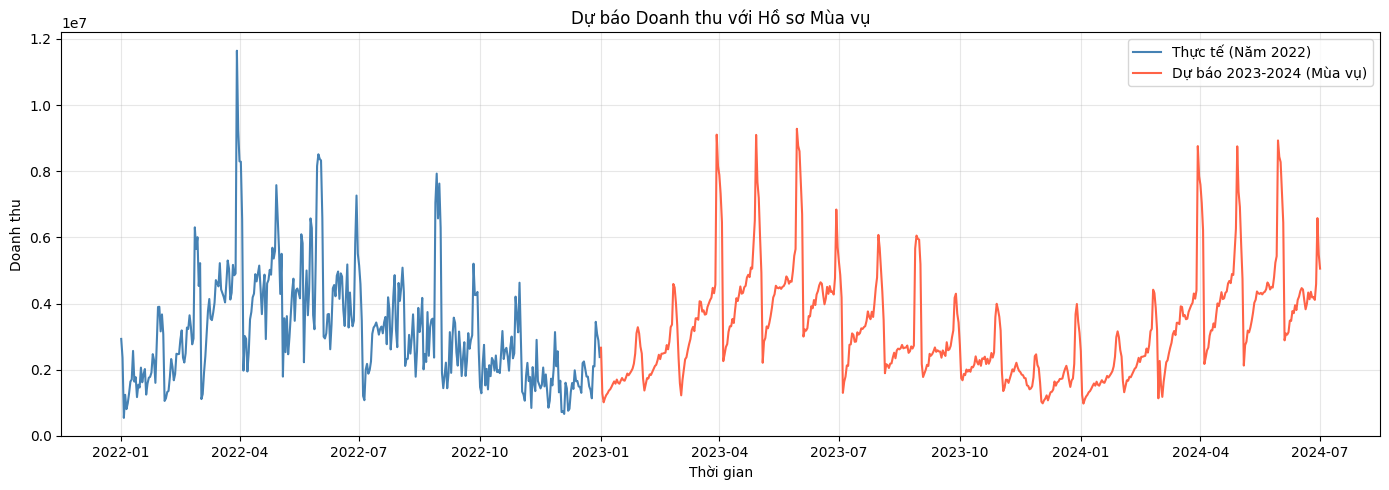

In [22]:
# [FIX 1] Lấy mốc cơ sở là trung bình ngày của năm 2022
# Chia cho số ngày THỰC TẾ trong dữ liệu (không chia cứng 365)
n_days_2022 = df_train[df_train['year'] == 2022].shape[0]
base_rev    = annual.loc[2022, 'Revenue'] / n_days_2022
base_cogs   = annual.loc[2022, 'COGS']    / n_days_2022
print(f"Số ngày thực tế của năm 2022 trong dữ liệu: {n_days_2022}")

# Chuẩn bị tập Test
test = df_sample.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Ghép hồ sơ mùa vụ vào tập test
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Xử lý ngày 29/02 (năm nhuận) nếu bị thiếu
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# CÔNG THỨC DỰ BÁO:
# Giá trị = (Mốc cơ sở) * (Tốc độ tăng trưởng ^ Số năm) * (Hệ số mùa vụ)
test['Revenue_pred'] = base_rev  * (growth_rev  ** test['years_ahead']) * test['rev_norm']
test['COGS_pred']    = base_cogs * (growth_cogs ** test['years_ahead']) * test['cogs_norm']

# [FIX 2] Dùng lọc theo năm thay vì slice integer để đảm bảo ổn định
train_2022 = df_train[df_train['year'] == 2022]
plt.figure(figsize=(14, 5))
plt.plot(train_2022['Date'], train_2022['Revenue'],  label='Thực tế (Năm 2022)', color='steelblue')
plt.plot(test['Date'], test['Revenue_pred'], label='Dự báo 2023-2024 (Mùa vụ)', color='tomato')
plt.title("Dự báo Doanh thu với Hồ sơ Mùa vụ")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Đánh giá mô hình trên Validation Set (2021-2022)

=== Đánh giá mô hình trên Validation Set (2021-2022) ===
  MAE   : 612,312
  RMSE  : 798,824
  R²    : 0.7704


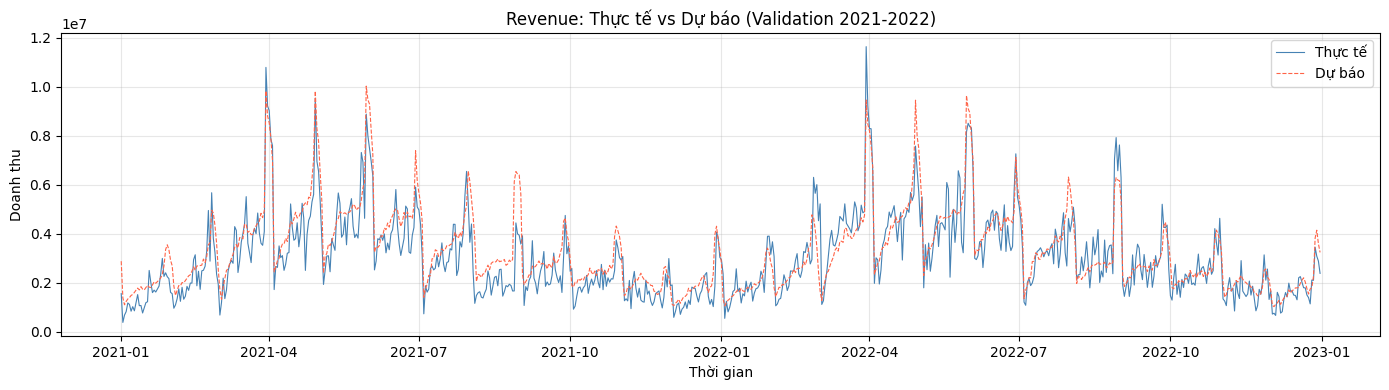

In [23]:
# [FIX 3] Áp dụng lại công thức lên 2 năm cuối của tập Train để tính chỉ số
val = df_train[df_train['year'].isin([2021, 2022])].copy()
# Fix lỗi KeyError khi merge: Bỏ các cột trùng lặp từ tập train trước khi merge với bảng seasonal
val = val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')
val = val.merge(seasonal, on=['month', 'day'], how='left')
val['rev_norm']  = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
val['years_ahead'] = val['year'] - 2022

val['Revenue_pred'] = base_rev  * (growth_rev  ** val['years_ahead']) * val['rev_norm']
val['COGS_pred']    = base_cogs * (growth_cogs ** val['years_ahead']) * val['cogs_norm']

mae  = mean_absolute_error(val['Revenue'], val['Revenue_pred'])
rmse = mean_squared_error(val['Revenue'], val['Revenue_pred']) ** 0.5
r2   = r2_score(val['Revenue'], val['Revenue_pred'])

print('=== Đánh giá mô hình trên Validation Set (2021-2022) ===')
print(f'  MAE   : {mae:,.0f}')
print(f'  RMSE  : {rmse:,.0f}')
print(f'  R²    : {r2:.4f}')

# Biểu đồ Thực tế vs Dự báo trên Validation
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],       label='Thực tế', lw=0.8, color='steelblue')
ax.plot(val['Date'], val['Revenue_pred'],  label='Dự báo',  lw=0.8, color='tomato', linestyle='--')
ax.set_title('Revenue: Thực tế vs Dự báo (Validation 2021-2022)')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Doanh thu')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Xuất file nộp bài (Submission)

In [24]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)

# Đảm bảo không có số âm
submission['Revenue'] = submission['Revenue'].clip(lower=0)
submission['COGS']    = submission['COGS'].clip(lower=0)

# Định dạng ngày tháng yyyy-mm-dd chuẩn Kaggle
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

submission.to_csv(OUTPUT_PATH, index=False)
print(f"Đã lưu file nộp bài tại: {OUTPUT_PATH}")
submission.head(10)

Đã lưu file nộp bài tại: ../submission_v1_seasonal.csv


,Date,Revenue,COGS
0,2023-01-01,2.665507e+06,2.518885e+06
1,2023-01-02,1.280008e+06,1.136463e+06
2,2023-01-03,1.015900e+06,8.227211e+05
3,2023-01-04,1.142997e+06,9.145542e+05
4,2023-01-05,1.236312e+06,9.843902e+05
5,2023-01-06,1.289095e+06,1.040418e+06
6,2023-01-07,1.370539e+06,1.119430e+06
7,2023-01-08,1.409122e+06,1.142951e+06
8,2023-01-09,1.483991e+06,1.221315e+06
9,2023-01-10,1.570643e+06,1.258682e+06
